In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

print("✅ Imports done")

In [ ]:
WESAD_PATH = "/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD"
SUBJECTS   = ['S2','S3','S4','S5','S6','S7','S8','S9','S10',
               'S11','S13','S14','S15','S16','S17']

FS = {'BVP': 64, 'EDA': 4, 'TEMP': 4, 'ACC': 32}

print("✅ Config ready")
print("Subjects:", SUBJECTS)

In [ ]:
def extract_statistical_features(segment, prefix):
    feats = {}
    feats[f'{prefix}_mean']   = np.mean(segment)
    feats[f'{prefix}_std']    = np.std(segment)
    feats[f'{prefix}_min']    = np.min(segment)
    feats[f'{prefix}_max']    = np.max(segment)
    feats[f'{prefix}_range']  = np.ptp(segment)
    feats[f'{prefix}_skew']   = skew(segment)
    feats[f'{prefix}_kurt']   = kurtosis(segment)
    feats[f'{prefix}_rms']    = np.sqrt(np.mean(segment**2))
    feats[f'{prefix}_iqr']    = np.percentile(segment,75) - np.percentile(segment,25)
    feats[f'{prefix}_median'] = np.median(segment)
    return feats

def extract_eda_features(segment, fs=4):
    feats = extract_statistical_features(segment, 'EDA')
    feats['EDA_slope'] = np.polyfit(np.arange(len(segment)), segment, 1)[0]
    peaks, _ = scipy_signal.find_peaks(segment, height=0.02, distance=int(fs*1))
    feats['EDA_scr_count']    = len(peaks)
    feats['EDA_scr_rate']     = len(peaks) / (len(segment) / fs)
    feats['EDA_scr_mean_amp'] = np.mean(segment[peaks]) if len(peaks) > 0 else 0.0
    return feats

def extract_bvp_features(segment, fs=64):
    feats = extract_statistical_features(segment, 'BVP')
    peaks, _ = scipy_signal.find_peaks(segment, distance=int(fs*0.4))
    if len(peaks) > 1:
        rr = np.diff(peaks) / fs * 1000
        feats['BVP_hr_mean'] = 60000 / np.mean(rr)
        feats['BVP_sdnn']    = np.std(rr)
        feats['BVP_rmssd']   = np.sqrt(np.mean(np.diff(rr)**2))
        feats['BVP_nn50']    = np.sum(np.abs(np.diff(rr)) > 50)
        feats['BVP_pnn50']   = feats['BVP_nn50'] / len(rr) if len(rr) > 0 else 0
    else:
        for k in ['BVP_hr_mean','BVP_sdnn','BVP_rmssd','BVP_nn50','BVP_pnn50']:
            feats[k] = 0.0
    return feats

def extract_temp_features(segment):
    feats = extract_statistical_features(segment, 'TEMP')
    feats['TEMP_slope'] = np.polyfit(np.arange(len(segment)), segment, 1)[0]
    return feats

def extract_acc_features(segment_3d):
    feats = {}
    for i, ax in enumerate(['x','y','z']):
        feats.update(extract_statistical_features(segment_3d[:,i], f'ACC_{ax}'))
    mag = np.sqrt(np.sum(segment_3d**2, axis=1))
    feats.update(extract_statistical_features(mag, 'ACC_mag'))
    feats['ACC_sma'] = np.sum(np.abs(segment_3d)) / len(segment_3d)
    return feats

print("✅ Feature extraction functions ready")

In [ ]:
def load_subject(subject_id):
    path = os.path.join(WESAD_PATH, subject_id, f'{subject_id}.pkl')
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

def resample_labels(labels, target_len, original_fs=700, target_fs=4):
    factor    = original_fs // target_fs
    n_out     = min(len(labels) // factor, target_len)
    resampled = np.array([
        np.bincount(labels[i*factor:(i+1)*factor].clip(0,4), minlength=5).argmax()
        for i in range(n_out)
    ])
    return resampled[:target_len]

def segment_subject(subject_id, window_sec=10, overlap=0.5):
    data       = load_subject(subject_id)
    wrist      = data['signal']['wrist']
    raw_labels = data['label'].flatten()

    eda  = wrist['EDA'].flatten()
    temp = wrist['TEMP'].flatten()
    bvp  = wrist['BVP'].flatten()
    acc  = wrist['ACC']

    base_fs   = 4
    win_base  = window_sec * base_fs      # 10s × 4Hz = 40 samples
    step      = int(win_base * (1 - overlap))  # 50% overlap → step=20
    LABEL_MAP = {1: 0, 2: 1}

    labels_base = resample_labels(raw_labels, len(eda))

    rows = []
    for start in range(0, len(eda) - win_base, step):
        end = start + win_base

        # Strict label: 80% of window must be same label
        win_labels     = labels_base[start:end]
        unique, counts = np.unique(win_labels, return_counts=True)
        dominant       = unique[np.argmax(counts)]
        dominant_ratio = np.max(counts) / len(win_labels)

        if dominant not in LABEL_MAP:
            continue
        if dominant_ratio < 0.8:   # skip mixed windows
            continue

        y = LABEL_MAP[dominant]

        seg_eda  = eda[start:end]
        seg_temp = temp[start:end]
        bs, be   = start*(FS['BVP']//base_fs), end*(FS['BVP']//base_fs)
        as_, ae  = start*(FS['ACC']//base_fs), end*(FS['ACC']//base_fs)
        seg_bvp  = bvp[bs:be]
        seg_acc  = acc[as_:ae]

        if len(seg_bvp) < 10 or seg_acc.shape[0] < 10:
            continue

        feats = {}
        feats.update(extract_eda_features(seg_eda,   fs=FS['EDA']))
        feats.update(extract_bvp_features(seg_bvp,   fs=FS['BVP']))
        feats.update(extract_temp_features(seg_temp))
        feats.update(extract_acc_features(seg_acc))
        feats['subject'] = subject_id
        feats['label']   = y
        rows.append(feats)

    return pd.DataFrame(rows)

# Reload all subjects
all_dfs = []
for sid in SUBJECTS:
    try:
        df_s = segment_subject(sid)
        all_dfs.append(df_s)
        print(f"  {sid}: {len(df_s)} windows")
    except Exception as e:
        print(f"  {sid}: FAILED — {e}")

df_all = pd.concat(all_dfs, ignore_index=True)
print(f"\n✅ Total windows: {len(df_all)}")
print(df_all['label'].value_counts())

In [ ]:
feature_cols = [c for c in df_all.columns if c not in ['subject','label']]

# Fill NaNs
df_all[feature_cols] = df_all[feature_cols].fillna(df_all[feature_cols].median())

# Remove corrupted rows
zero_mask = (df_all[feature_cols] == 0).all(axis=1)
df_all    = df_all[~zero_mask].reset_index(drop=True)

# Clip outliers
for col in feature_cols:
    q1, q3     = df_all[col].quantile(0.25), df_all[col].quantile(0.75)
    iqr        = q3 - q1
    df_all[col] = df_all[col].clip(q1 - 5*iqr, q3 + 5*iqr)

# Intensity score → 3-state labels
def compute_intensity(sdf):
    def norm(col):
        mn, mx = col.min(), col.max()
        return (col - mn) / (mx - mn + 1e-6)
    return (
        norm(sdf['EDA_mean'])        +
        norm(sdf['BVP_hr_mean'])     +
        (1 - norm(sdf['BVP_sdnn'])) +
        (1 - norm(sdf['TEMP_mean']))
    ) / 4

stress_df     = df_all[df_all['label'] == 1].copy()
labeled_parts = []

for sid, group in stress_df.groupby('subject'):
    group              = group.copy()
    group['intensity'] = compute_intensity(group)
    threshold          = group['intensity'].median()
    gap                = 0.12
    group['label_3']   = group['intensity'].apply(
        lambda x: 1 if x < threshold - gap else (2 if x > threshold + gap else -1)
    )
    group = group[group['label_3'] != -1]
    labeled_parts.append(group)

stress_df          = pd.concat(labeled_parts)
calm_df            = df_all[df_all['label'] == 0].copy()
calm_df['label_3'] = 0
df_final           = pd.concat([calm_df, stress_df]).reset_index(drop=True)

print("✅ 3-state labels created!")
print("\nState distribution:")
total = len(df_final)
for label, name in zip([0,1,2], ['Calm','Mild','High']):
    count = (df_final['label_3'] == label).sum()
    print(f"  {name:6s}: {count:5d} ({100*count/total:.1f}%)")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

HIDDEN_DIM = 128
BATCH_SIZE = 64
NOISE_DIM  = 64

# How many synthetic samples to generate per class
N_SYNTHETIC = {
    0:    0,   # Calm  — already enough real data
    1: 2500,   # Mild  — needs boost
    2: 3000    # High  — needs biggest boost
}

def build_generator(input_dim, hidden_dim):
    return keras.Sequential([
        keras.layers.Input(shape=(NOISE_DIM,)),
        keras.layers.Dense(hidden_dim, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(hidden_dim, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(hidden_dim, activation='relu'),
        keras.layers.Dense(input_dim,  activation='sigmoid')
    ])

def build_discriminator(input_dim, hidden_dim):
    return keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(hidden_dim, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(hidden_dim, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])

def train_feature_gan(X_data, class_label, epochs=3000):
    print(f"\n{'='*50}")
    print(f"Training GAN — Class {class_label} | Samples: {len(X_data)}")
    print(f"{'='*50}")

    input_dim     = X_data.shape[1]
    generator     = build_generator(input_dim, HIDDEN_DIM)
    discriminator = build_discriminator(input_dim, HIDDEN_DIM)

    bce   = keras.losses.BinaryCrossentropy(label_smoothing=0.1)
    opt_g = keras.optimizers.Adam(1e-4)
    opt_d = keras.optimizers.Adam(1e-4)

    dataset = tf.data.Dataset.from_tensor_slices(X_data)\
                .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    for epoch in range(epochs):
        for X_batch in dataset:
            batch_size = tf.shape(X_batch)[0]
            Z          = tf.random.normal(shape=(batch_size, NOISE_DIM))

            # Train Discriminator
            with tf.GradientTape() as tape:
                fake     = generator(Z,       training=False)
                real_out = discriminator(X_batch, training=True)
                fake_out = discriminator(fake,    training=True)
                loss_d   = bce(tf.ones_like(real_out),  real_out) + \
                           bce(tf.zeros_like(fake_out), fake_out)
            opt_d.apply_gradients(zip(
                tape.gradient(loss_d, discriminator.trainable_variables),
                discriminator.trainable_variables
            ))

            # Train Generator
            with tf.GradientTape() as tape:
                fake     = generator(Z,    training=True)
                fake_out = discriminator(fake, training=False)
                loss_g   = bce(tf.ones_like(fake_out), fake_out)
            opt_g.apply_gradients(zip(
                tape.gradient(loss_g, generator.trainable_variables),
                generator.trainable_variables
            ))

        if epoch % 500 == 0:
            print(f"  Epoch {epoch:4d} | G: {loss_g:.4f} | D: {loss_d:.4f}")

    print(f"✅ Class {class_label} GAN done!")
    return generator

# Scale features to [0,1] for GAN
scalers    = {}
scaled_dfs = {}

for cls in [0, 1, 2]:
    subset         = df_final[df_final['label_3'] == cls][feature_cols].values.astype(np.float32)
    sc             = MinMaxScaler()
    scaled         = sc.fit_transform(subset)
    scalers[cls]   = sc
    scaled_dfs[cls] = scaled
    print(f"Class {cls}: {scaled.shape}")

# Train GANs only for minority classes
trained_generators = {}
for cls in [1, 2]:   # skip class 0, no synthetic needed
    gen = train_feature_gan(scaled_dfs[cls], class_label=cls, epochs=3000)
    trained_generators[cls] = gen

print("\n🎉 All GANs trained!")

In [ ]:
synthetic_rows = []

for cls in [1, 2]:
    gen = trained_generators[cls]
    sc  = scalers[cls]
    n   = N_SYNTHETIC[cls]

    Z           = tf.random.normal(shape=(n, NOISE_DIM))
    fake_scaled = gen(Z, training=False).numpy()
    fake_orig   = sc.inverse_transform(fake_scaled)

    df_syn            = pd.DataFrame(fake_orig, columns=feature_cols)
    df_syn['label_3'] = cls
    df_syn['subject'] = 'synthetic'
    synthetic_rows.append(df_syn)
    print(f"Class {cls}: generated {n} synthetic samples")

df_synthetic = pd.concat(synthetic_rows, ignore_index=True)

# Combine real + synthetic
df_combined = pd.concat([df_final, df_synthetic], ignore_index=True)

print(f"\n✅ Combined dataset shape: {df_combined.shape}")
print("\nFinal class distribution:")
total = len(df_combined)
for label, name in zip([0,1,2], ['Calm','Mild','High']):
    count = (df_combined['label_3'] == label).sum()
    print(f"  {name:6s}: {count:5d} ({100*count/total:.1f}%)")

In [ ]:
import joblib

# Save synthetic dataframe
df_synthetic.to_csv('/kaggle/working/synthetic_data.csv', index=False)

# Save combined dataframe
df_combined.to_csv('/kaggle/working/combined_data.csv', index=False)

# Save real final dataframe
df_final.to_csv('/kaggle/working/real_data.csv', index=False)

# Save scalers
joblib.dump(scalers, '/kaggle/working/gan_scalers.pkl')

# Save trained generators
for cls in [1, 2]:
    trained_generators[cls].save(f'/kaggle/working/gan_generator_class{cls}.keras')

print("✅ Saved:")
print("  - synthetic_data.csv")
print("  - combined_data.csv")
print("  - real_data.csv")
print("  - gan_scalers.pkl")
print("  - gan_generator_class1.keras")
print("  - gan_generator_class2.keras")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, recall_score)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))

class SmartCalmMLP(nn.Module):
    def __init__(self, input_dim, hidden=128, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.res1 = ResidualBlock(hidden, dropout)
        self.res2 = ResidualBlock(hidden, dropout)
        self.res3 = ResidualBlock(hidden, dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 3)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res1(x); x = self.res2(x); x = self.res3(x)
        return self.head(x)

def train_model(X_tr, y_tr, X_val, y_val, input_dim, epochs=100, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = SmartCalmMLP(input_dim).to(device)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_tr, minlength=3)
    w      = torch.tensor(counts.sum() / (3*counts + 1e-6), dtype=torch.float).to(device)
    w[1]  *= 1.4
    w[2]  *= 1.4
    w      = w / w.sum() * 3
    crit   = nn.CrossEntropyLoss(weight=w)

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        ),
        batch_size=128, shuffle=True
    )

    best_recall, best_state = 0, None
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        sched.step()

        if (epoch + 1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                pv    = model(torch.tensor(X_val, dtype=torch.float32).to(device))
                preds = pv.argmax(1).cpu().numpy()
            val_recall = recall_score(y_val, preds, average='macro', zero_division=0)
            if val_recall > best_recall:
                best_recall = val_recall
                best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state:
        model.load_state_dict(best_state)
    return model

# LOSO — train on real+synthetic, test on real only
results    = []
all_preds  = []
all_labels = []
all_probs  = []
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Starting LOSO training...\n")

for test_sid in SUBJECTS:
    # Test set = only real data for this subject
    test_df    = df_final[df_final['subject'] == test_sid]

    # Train set = all other real subjects + all synthetic
    real_train = df_final[df_final['subject'] != test_sid]
    train_df   = pd.concat([real_train, df_synthetic], ignore_index=True)

    X_tr = train_df[feature_cols].values.astype(np.float32)
    y_tr = train_df['label_3'].values
    X_te = test_df[feature_cols].values.astype(np.float32)
    y_te = test_df['label_3'].values

    scaler = RobustScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    model  = train_model(X_tr, y_tr, X_te, y_te, input_dim=X_tr.shape[1])

    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_te, dtype=torch.float32).to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = probs.argmax(1)

    acc    = accuracy_score(y_te, preds)
    f1     = f1_score(y_te, preds, average='macro', zero_division=0)
    recall = recall_score(y_te, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_te, probs, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0

    results.append({'subject': test_sid, 'acc': acc,
                    'f1': f1, 'recall': recall, 'auc': auc})
    all_preds.extend(preds)
    all_labels.extend(y_te)
    all_probs.extend(probs)
    print(f"  {test_sid} → Acc: {acc:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
print("\n✅ LOSO complete!")

In [ ]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)

print("\n" + "="*50)
print("     FINAL RESULTS (Real + Synthetic)")
print("="*50)
print(f"  Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"  Recall   : {recall_score(all_labels, all_preds, average='macro'):.4f}")
print(f"  F1 Score : {f1_score(all_labels, all_preds, average='macro'):.4f}")
try:
    print(f"  AUC-ROC  : {roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro'):.4f}")
except Exception:
    pass

print()
print(classification_report(
    all_labels, all_preds,
    target_names=['Calm','Mild','High']
))

# Confusion matrix
cm  = confusion_matrix(all_labels, all_preds, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Calm','Mild','High']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Calm / Mild / High', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# Per subject metrics
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, m, t, c in zip(
    axes,
    ['acc', 'recall', 'f1'],
    ['Accuracy', 'Recall', 'F1'],
    ['#4CAF50', '#F44336', '#2196F3']
):
    ax.bar(res_df['subject'], res_df[m], color=c, alpha=0.8)
    ax.axhline(res_df[m].mean(), color='black', linestyle='--',
               label=f'Mean={res_df[m].mean():.3f}')
    ax.set_title(t, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('SmartCalm — LOSO Results (Real + Synthetic)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/loso_results.png', dpi=150)
plt.show()

In [ ]:
import torch

# Save best model from last LOSO fold as reference
# (in production you'd retrain on ALL data)
torch.save(model.state_dict(), '/kaggle/working/smartcalm_mlp.pth')

# Save the scaler from last fold (for inference reference)
joblib.dump(scaler, '/kaggle/working/mlp_scaler.pkl')

# Save results dataframe
res_df.to_csv('/kaggle/working/loso_results.csv', index=False)

print("✅ Saved:")
print("  - smartcalm_mlp.pth       (model weights)")
print("  - mlp_scaler.pkl          (feature scaler)")
print("  - loso_results.csv        (per subject results)")
print("  - confusion_matrix.png    (confusion matrix plot)")
print("  - loso_results.png        (per subject metrics plot)")
print("\n📦 All files are in /kaggle/working/")
print("   Download them from Output tab on the right side of Kaggle!")

In [ ]:
import os
for folder in os.listdir('/kaggle/input'):
    print(folder)

In [ ]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))

class SmartCalmMLP(nn.Module):
    def __init__(self, input_dim, hidden=128, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.res1 = ResidualBlock(hidden, dropout)
        self.res2 = ResidualBlock(hidden, dropout)
        self.res3 = ResidualBlock(hidden, dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 3)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res1(x); x = self.res2(x); x = self.res3(x)
        return self.head(x)

In [ ]:
import os
for f in os.listdir('/kaggle/input/notebooks/hibahamed/gan-final'):
    print(f)

In [ ]:
model = SmartCalmMLP(input_dim=81)
model.load_state_dict(torch.load('/kaggle/input/notebooks/hibahamed/gan-final/smartcalm_mlp.pth', map_location='cpu'))
model.eval()
print("✅ Model loaded!")

In [ ]:
import torch.onnx

dummy_input = torch.randn(1, 81)

torch.onnx.export(
    model,
    dummy_input,
    '/kaggle/working/smartcalm_mlp.onnx',
    export_params=True,
    opset_version=17,
    input_names=['features'],
    output_names=['logits'],
    dynamic_axes={
        'features': {0: 'batch_size'},
        'logits':   {0: 'batch_size'}
    }
)
print("✅ ONNX export done!")

In [ ]:
!pip install onnxscript -q

In [ ]:
import onnx

onnx_model = onnx.load('/kaggle/working/smartcalm_mlp.onnx')
onnx.checker.check_model(onnx_model)
print("✅ ONNX model is valid!")

In [ ]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession('/kaggle/working/smartcalm_mlp.onnx')
dummy = np.random.randn(1, 81).astype(np.float32)
logits = sess.run(['logits'], {'features': dummy})[0]
pred = np.argmax(logits)
print(f"✅ Test prediction: {['Calm', 'Mild', 'High'][pred]}")

In [ ]:
!pip install onnxruntime -q

In [29]:
import shutil
shutil.copy('/kaggle/input/notebooks/hibahamed/gan-final/mlp_scaler.pkl', '/kaggle/working/mlp_scaler.pkl')
print("✅ Scaler copied to output!")

✅ Scaler copied to output!


         SMARTCALM — FULL PROJECT REPORT

📊 1. DATA OVERVIEW
----------------------------------------
  Real samples      : 4217
  Synthetic samples : 5500
  Combined total    : 9717

  Real data class distribution:
      Calm (0): 3503 samples (83.1%)
      Mild (1): 408 samples (9.7%)
      High (2): 306 samples (7.3%)

  Synthetic data class distribution:
      Mild (1): 2500 samples (45.5%)
      High (2): 3000 samples (54.5%)

  Combined data class distribution:
      Calm (0): 3503 samples (36.1%)
      Mild (1): 2908 samples (29.9%)
      High (2): 3306 samples (34.0%)

  Number of features : 83
  Number of subjects : 15

📈 2. PER-SUBJECT LOSO RESULTS
----------------------------------------
subject      acc       f1   recall      auc
     S2 0.969697 0.927982 0.913165 0.995358
     S3 0.858238 0.762525 0.918075 0.970484
     S4 0.996094 0.925926 0.985507 0.999938
     S5 0.989583 0.971097 0.995798 0.997898
     S6 0.932584 0.853509 0.926001 0.971123
     S7 0.920690 0.839987 0.

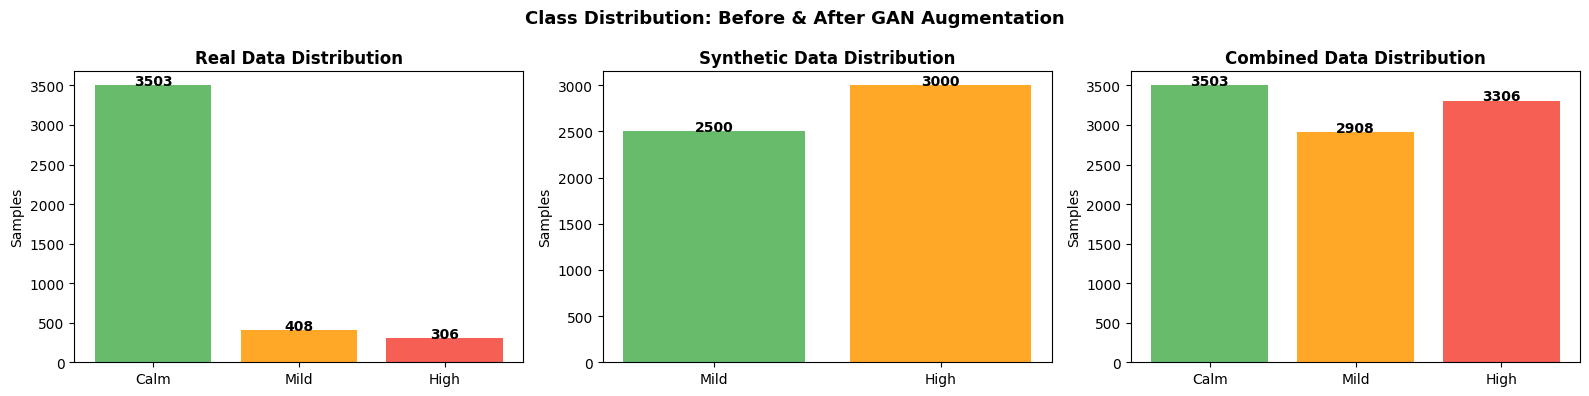

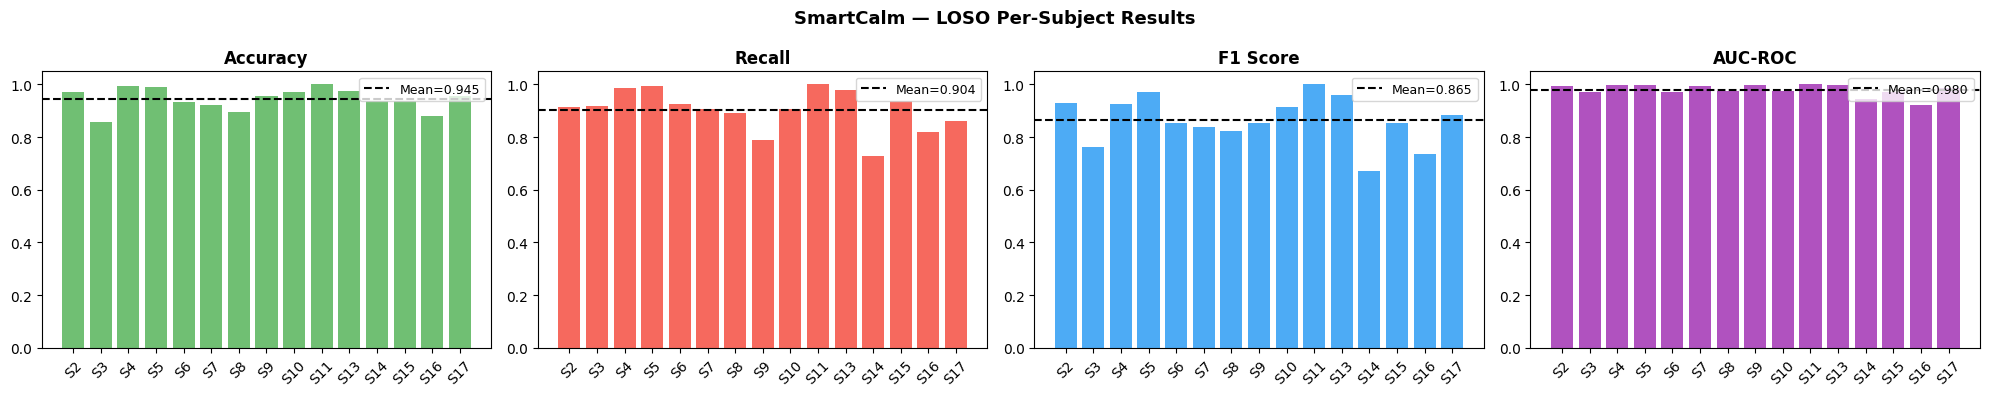

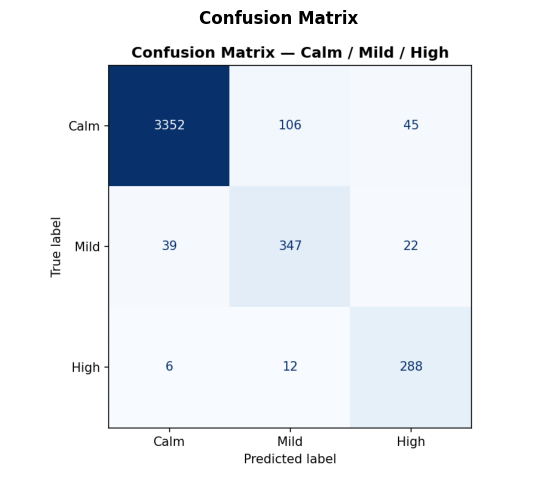


✅ Full report complete!
   Saved: class_distribution.png, loso_metrics.png


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

BASE = '/kaggle/input/notebooks/hibahamed/gan-final'

print("="*60)
print("         SMARTCALM — FULL PROJECT REPORT")
print("="*60)

# ── 1. DATA OVERVIEW ──────────────────────────────────────────
real_df      = pd.read_csv(f'{BASE}/real_data.csv')
synthetic_df = pd.read_csv(f'{BASE}/synthetic_data.csv')
combined_df  = pd.read_csv(f'{BASE}/combined_data.csv')

label_map = {0: 'Calm', 1: 'Mild', 2: 'High'}

print("\n📊 1. DATA OVERVIEW")
print("-"*40)
print(f"  Real samples      : {len(real_df)}")
print(f"  Synthetic samples : {len(synthetic_df)}")
print(f"  Combined total    : {len(combined_df)}")

print("\n  Real data class distribution:")
for k, v in real_df['label_3'].value_counts().sort_index().items():
    print(f"    {label_map[k]:>6} ({k}): {v} samples ({v/len(real_df)*100:.1f}%)")

print("\n  Synthetic data class distribution:")
for k, v in synthetic_df['label_3'].value_counts().sort_index().items():
    print(f"    {label_map[k]:>6} ({k}): {v} samples ({v/len(synthetic_df)*100:.1f}%)")

print("\n  Combined data class distribution:")
for k, v in combined_df['label_3'].value_counts().sort_index().items():
    print(f"    {label_map[k]:>6} ({k}): {v} samples ({v/len(combined_df)*100:.1f}%)")

print(f"\n  Number of features : {len([c for c in real_df.columns if c not in ['label_3','subject']])}")
print(f"  Number of subjects : {real_df['subject'].nunique()}")

# ── 2. PER-SUBJECT LOSO RESULTS ───────────────────────────────
res_df = pd.read_csv(f'{BASE}/loso_results.csv')

print("\n📈 2. PER-SUBJECT LOSO RESULTS")
print("-"*40)
print(res_df.to_string(index=False))

print("\n  MEAN METRICS:")
print(f"    Accuracy : {res_df['acc'].mean():.4f}  (±{res_df['acc'].std():.4f})")
print(f"    Recall   : {res_df['recall'].mean():.4f}  (±{res_df['recall'].std():.4f})")
print(f"    F1 Score : {res_df['f1'].mean():.4f}  (±{res_df['f1'].std():.4f})")
print(f"    AUC-ROC  : {res_df['auc'].mean():.4f}  (±{res_df['auc'].std():.4f})")

print(f"\n  BEST SUBJECT  : {res_df.loc[res_df['acc'].idxmax(), 'subject']} (Acc: {res_df['acc'].max():.4f})")
print(f"  WORST SUBJECT : {res_df.loc[res_df['acc'].idxmin(), 'subject']} (Acc: {res_df['acc'].min():.4f})")

# ── 3. FEATURE STATS ──────────────────────────────────────────
feature_cols = [c for c in real_df.columns if c not in ['label_3', 'subject']]

print("\n🔬 3. FEATURE STATISTICS (Real Data)")
print("-"*40)
print(real_df[feature_cols].describe().round(4).to_string())

# ── 4. GAN INFO ───────────────────────────────────────────────
print("\n🤖 4. GAN INFO")
print("-"*40)
gan_scalers = joblib.load(f'{BASE}/gan_scalers.pkl')
print(f"  GAN scalers loaded : {list(gan_scalers.keys()) if isinstance(gan_scalers, dict) else type(gan_scalers)}")
print(f"  Synthetic samples generated per class:")
for k, v in synthetic_df['label_3'].value_counts().sort_index().items():
    print(f"    {label_map[k]:>6} ({k}): {v} samples")

# ── 5. PLOTS ──────────────────────────────────────────────────
print("\n📉 5. PLOTS")
print("-"*40)

# Class distribution before vs after GAN
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Real distribution
real_counts = real_df['label_3'].value_counts().sort_index()
axes[0].bar([label_map[i] for i in real_counts.index], real_counts.values, color=['#4CAF50','#FF9800','#F44336'], alpha=0.85)
axes[0].set_title('Real Data Distribution', fontweight='bold')
axes[0].set_ylabel('Samples')
for i, v in enumerate(real_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Synthetic distribution
syn_counts = synthetic_df['label_3'].value_counts().sort_index()
axes[1].bar([label_map[i] for i in syn_counts.index], syn_counts.values, color=['#4CAF50','#FF9800','#F44336'], alpha=0.85)
axes[1].set_title('Synthetic Data Distribution', fontweight='bold')
axes[1].set_ylabel('Samples')
for i, v in enumerate(syn_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Combined distribution
comb_counts = combined_df['label_3'].value_counts().sort_index()
axes[2].bar([label_map[i] for i in comb_counts.index], comb_counts.values, color=['#4CAF50','#FF9800','#F44336'], alpha=0.85)
axes[2].set_title('Combined Data Distribution', fontweight='bold')
axes[2].set_ylabel('Samples')
for i, v in enumerate(comb_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before & After GAN Augmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
plt.show()

# Per subject metrics
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, m, t, c in zip(
    axes,
    ['acc', 'recall', 'f1', 'auc'],
    ['Accuracy', 'Recall', 'F1 Score', 'AUC-ROC'],
    ['#4CAF50', '#F44336', '#2196F3', '#9C27B0']
):
    ax.bar(res_df['subject'], res_df[m], color=c, alpha=0.8)
    ax.axhline(res_df[m].mean(), color='black', linestyle='--', label=f'Mean={res_df[m].mean():.3f}')
    ax.set_title(t, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
plt.suptitle('SmartCalm — LOSO Per-Subject Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/loso_metrics.png', dpi=150)
plt.show()

# Show saved confusion matrix
img = Image.open(f'{BASE}/confusion_matrix.png')
plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Full report complete!")
print("   Saved: class_distribution.png, loso_metrics.png")

       GAN QUALITY EVALUATION

📊 1. MEAN & STD COMPARISON (Real vs Synthetic)
--------------------------------------------------

  Class: Mild
    Real      — Mean: 30.2384 | Std: 106.9368
    Synthetic — Mean: 30.9298 | Std: 113.8952
    Mean diff : 0.6914 ⚠️ Check
    Std diff  : 6.9583  ⚠️ Check

  Class: High
    Real      — Mean: 19.9688 | Std: 65.5942
    Synthetic — Mean: 20.1168 | Std: 60.1905
    Mean diff : 0.1480 ⚠️ Check
    Std diff  : 5.4037  ⚠️ Check

📐 2. KOLMOGOROV-SMIRNOV TEST (Real vs Synthetic)
--------------------------------------------------
  p-value > 0.05 = distributions are similar ✅

  Class Mild:
    Features passing (p>0.05) : 10/81 (12.3%) ✅
    Features failing (p≤0.05) : 71/81 (87.7%)
  Class High:
    Features passing (p>0.05) : 7/81 (8.6%) ✅
    Features failing (p≤0.05) : 74/81 (91.4%)


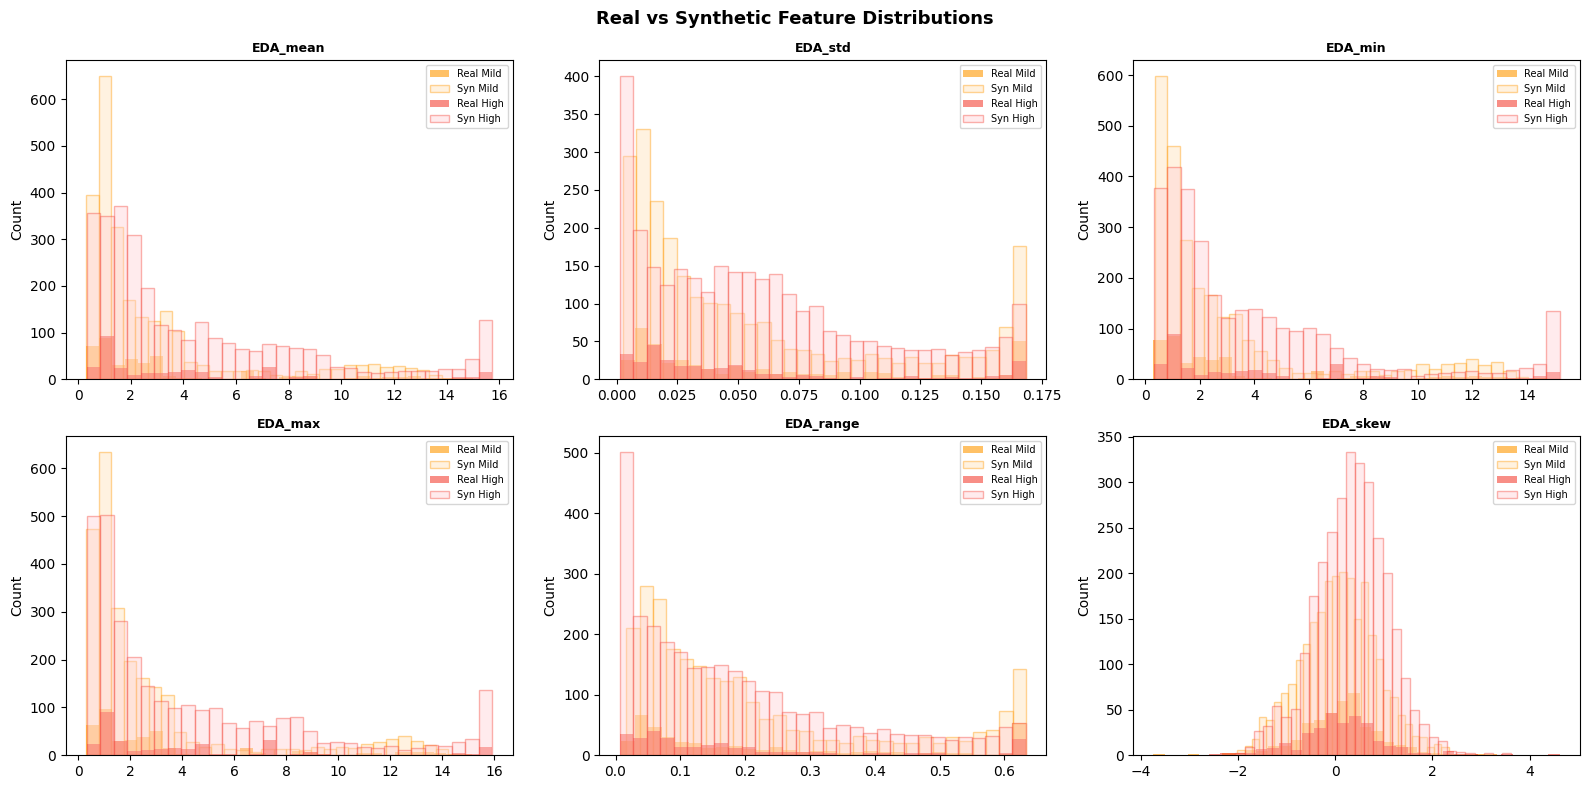


🔗 4. CORRELATION STRUCTURE SIMILARITY
--------------------------------------------------
  Class Mild — Correlation matrix difference: 12.0822 ⚠️ Different
  Class High — Correlation matrix difference: 11.1476 ⚠️ Different

✅ GAN quality evaluation complete!
   Saved: gan_quality.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from scipy import stats

BASE = '/kaggle/input/notebooks/hibahamed/gan-final'

real_df      = pd.read_csv(f'{BASE}/real_data.csv')
synthetic_df = pd.read_csv(f'{BASE}/synthetic_data.csv')

# ✅ Fixed feature columns
feature_cols = [c for c in real_df.columns if c not in ['label_3', 'label', 'intensity', 'subject']]
label_map    = {0: 'Calm', 1: 'Mild', 2: 'High'}

print("="*60)
print("       GAN QUALITY EVALUATION")
print("="*60)

# ── 1. Mean & Std comparison per class ───────────────────────
print("\n📊 1. MEAN & STD COMPARISON (Real vs Synthetic)")
print("-"*50)
for cls in [1, 2]:
    real_cls = real_df[real_df['label_3'] == cls][feature_cols]
    syn_cls  = synthetic_df[synthetic_df['label_3'] == cls][feature_cols]
    print(f"\n  Class: {label_map[cls]}")
    print(f"    Real      — Mean: {real_cls.values.mean():.4f} | Std: {real_cls.values.std():.4f}")
    print(f"    Synthetic — Mean: {syn_cls.values.mean():.4f} | Std: {syn_cls.values.std():.4f}")
    mean_diff = abs(real_cls.values.mean() - syn_cls.values.mean())
    std_diff  = abs(real_cls.values.std()  - syn_cls.values.std())
    print(f"    Mean diff : {mean_diff:.4f} {'✅ Good' if mean_diff < 0.1 else '⚠️ Check'}")
    print(f"    Std diff  : {std_diff:.4f}  {'✅ Good' if std_diff  < 0.1 else '⚠️ Check'}")

# ── 2. KS Test ────────────────────────────────────────────────
print("\n📐 2. KOLMOGOROV-SMIRNOV TEST (Real vs Synthetic)")
print("-"*50)
print("  p-value > 0.05 = distributions are similar ✅\n")

for cls in [1, 2]:
    real_cls = real_df[real_df['label_3'] == cls][feature_cols]
    syn_cls  = synthetic_df[synthetic_df['label_3'] == cls][feature_cols]
    passed, failed = 0, 0
    for col in feature_cols:
        _, p = stats.ks_2samp(real_cls[col].values, syn_cls[col].values)
        if p > 0.05:
            passed += 1
        else:
            failed += 1
    total = passed + failed
    print(f"  Class {label_map[cls]}:")
    print(f"    Features passing (p>0.05) : {passed}/{total} ({passed/total*100:.1f}%) ✅")
    print(f"    Features failing (p≤0.05) : {failed}/{total} ({failed/total*100:.1f}%)")

# ── 3. Feature distribution plots ────────────────────────────
top_features = feature_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    for cls, color_r, color_s in [(1, '#FF9800', '#FFE0B2'), (2, '#F44336', '#FFCDD2')]:
        real_vals = real_df[real_df['label_3'] == cls][col].values
        syn_vals  = synthetic_df[synthetic_df['label_3'] == cls][col].values
        axes[i].hist(real_vals, bins=30, alpha=0.6, color=color_r, label=f'Real {label_map[cls]}')
        axes[i].hist(syn_vals,  bins=30, alpha=0.4, color=color_s, label=f'Syn {label_map[cls]}', edgecolor=color_r)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Count')

plt.suptitle('Real vs Synthetic Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/gan_quality.png', dpi=150)
plt.show()

# ── 4. Correlation structure ──────────────────────────────────
print("\n🔗 4. CORRELATION STRUCTURE SIMILARITY")
print("-"*50)
for cls in [1, 2]:
    real_cls  = real_df[real_df['label_3'] == cls][feature_cols]
    syn_cls   = synthetic_df[synthetic_df['label_3'] == cls][feature_cols]
    real_corr = real_cls.corr().values
    syn_corr  = syn_cls.corr().values
    diff = np.linalg.norm(real_corr - syn_corr, 'fro')
    print(f"  Class {label_map[cls]} — Correlation matrix difference: {diff:.4f} {'✅ Similar' if diff < 10 else '⚠️ Different'}")

print("\n✅ GAN quality evaluation complete!")
print("   Saved: gan_quality.png")